# Урок 15.4. Техника пределов и непрерывность

**Интерактивная версия:** `lessons/lesson_15_4/web/index.html`

**После урока вы сможете:** находить пределы по правилам и заменой переменной, отличать определённые формы
от семи неопределённостей и раскрывать их (сокращение, сопряжённое, старшая степень, общий знаменатель),
пользоваться теоремой о сжатии, замечательными пределами и эквивалентностями, сравнивать скорости роста,
проверять непрерывность и классифицировать разрывы, применять теоремы о промежуточном значении
и Вейерштрасса — и видеть всё это в бустинге: разрывные деревья, гладкий log-loss, число $e$ в ансамблях,
устойчивые формулы.

Блоки урока:

1. **Правила:** арифметика пределов, сложная функция и замена, арифметика с бесконечностью, семь неопределённостей.
2. **Алгебраические приёмы:** гонка к нулю, сокращение, сопряжённое, старшая степень, $\infty - \infty$ и $0 \cdot \infty$.
3. **Сжатие и замечательные пределы:** два милиционера, $\frac{\sin x}{x}$, число $e$ и $1^\infty$, экспонента и логарифм.
4. **Сравнение скоростей:** порядок малости, эквивалентности и их ловушка, иерархия роста.
5. **Непрерывность:** разрывы и доопределение, склейка кусков, промежуточное значение, теорема Вейерштрасса.
6. **В ML:** деревья разрывны, accuracy против log-loss, число $e$ в бэггинге и бустинге, устойчивые формулы.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import math

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display
from matplotlib import animation
from scipy import optimize, special

from gbcourse.boosting import GBRegressor
from gbcourse.losses import get_loss
from gbcourse.plotting import use_course_style
from gbcourse.rng import Mulberry32
from gbcourse.style import AQUA, BLUE, MAGENTA, MUTED, ORANGE, RED, VIOLET

use_course_style()
plt.rcParams["animation.embed_limit"] = 30


def table(f, a, steps=(0.1, 0.01, 0.001)):
    """Значения f слева (a − 0.1, a − 0.01, a − 0.001) и справа (a + 0.001, …) от точки a."""
    left = [f(a - d) for d in steps]
    right = [f(a + d) for d in steps[::-1]]
    return "  ".join(f"{v:10.6f}" for v in left + right)

## Блок 1. Правила

### 1.1. Арифметика пределов

Если $\lim f = A$ и $\lim g = B$ конечны, то $\lim (f \pm g) = A \pm B$, $\lim fg = AB$, $\lim \frac fg = \frac AB$
при $B \ne 0$. Отклонение суммы не больше суммы отклонений — проверим это численно.

In [2]:
f = lambda x: x**2  # noqa: E731
g = lambda x: 3 * x - 1  # noqa: E731
a, A, B = 2, 4, 5
for d in (0.1, 0.01, 0.001):
    x = a + d
    dev_sum = abs(f(x) + g(x) - (A + B))
    print(f"d = {d:<6}: |f − A| + |g − B| = {abs(f(x) - A) + abs(g(x) - B):.6f} ≥ |(f + g) − (A + B)| = {dev_sum:.6f}")
print("многочлен 2x³ − x + 5 при x → −1:", table(lambda x: 2 * x**3 - x + 5, -1), "→ 4")

d = 0.1   : |f − A| + |g − B| = 0.710000 ≥ |(f + g) − (A + B)| = 0.710000
d = 0.01  : |f − A| + |g − B| = 0.070100 ≥ |(f + g) − (A + B)| = 0.070100
d = 0.001 : |f − A| + |g − B| = 0.007001 ≥ |(f + g) − (A + B)| = 0.007001
многочлен 2x³ − x + 5 при x → −1:   3.438000    3.949398    3.994994    4.004994    4.049402    4.442000 → 4


### 1.2. Предел сложной функции и замена переменной

$\lim f(g(x)) = f(\lim g(x))$, если внешняя функция непрерывна. Контрпример — внешняя ступенька:
$[\,-x^2 \ge 0\,]$ равна 0 при всех $x \ne 0$, хотя «$[0 \ge 0]$» = 1.

In [3]:
print("e^(sin x), x → 0:      ", table(lambda x: np.exp(np.sin(x)), 0), "→ 1")
print("ln((x²−1)/(x−1)), x → 1:", table(lambda x: np.log((x**2 - 1) / (x - 1)), 1), "→ ln 2 =", round(np.log(2), 6))
step = lambda u: float(u >= 0)  # noqa: E731
print("[−x² ≥ 0], x → 0:      ", table(lambda x: step(-(x**2)), 0), "→ 0, а f(0) = 1")

e^(sin x), x → 0:         0.904988    0.990050    0.999000    1.001000    1.010050    1.104987 → 1
ln((x²−1)/(x−1)), x → 1:   0.641854    0.688135    0.692647    0.693647    0.698135    0.741937 → ln 2 = 0.693147
[−x² ≥ 0], x → 0:         0.000000    0.000000    0.000000    0.000000    0.000000    0.000000 → 0, а f(0) = 1


### 1.3. Определённые формы и семь неопределённостей

Три выражения одной формы — три разных предела. Строим на двойной логарифмической шкале при $x \to +\infty$.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


0/0    (1/x²)/(1/x)    : x = 10 → 0.1, x = 1000 → 0.001
0/0    (2/x)/(1/x)     : x = 10 → 2, x = 1000 → 2
0/0    (1/x)/(1/x²)    : x = 10 → 10, x = 1000 → 1000
∞ − ∞  √(x²+1) − x     : x = 10 → 0.04988, x = 1000 → 0.0005
∞ − ∞  √(x²+4x) − x    : x = 10 → 1.832, x = 1000 → 1.998
∞ − ∞  x² − x          : x = 10 → 90, x = 1000 → 9.99e+05
1^∞    (1 − 1/x)^(x²)  : x = 10 → 2.656e-05, x = 1000 → 0
1^∞    (1 + 2/x)^x     : x = 10 → 6.192, x = 1000 → 7.374
1^∞    (1 + 1/x)^(x²)  : x = 10 → 1.378e+04, x = 1000 → inf


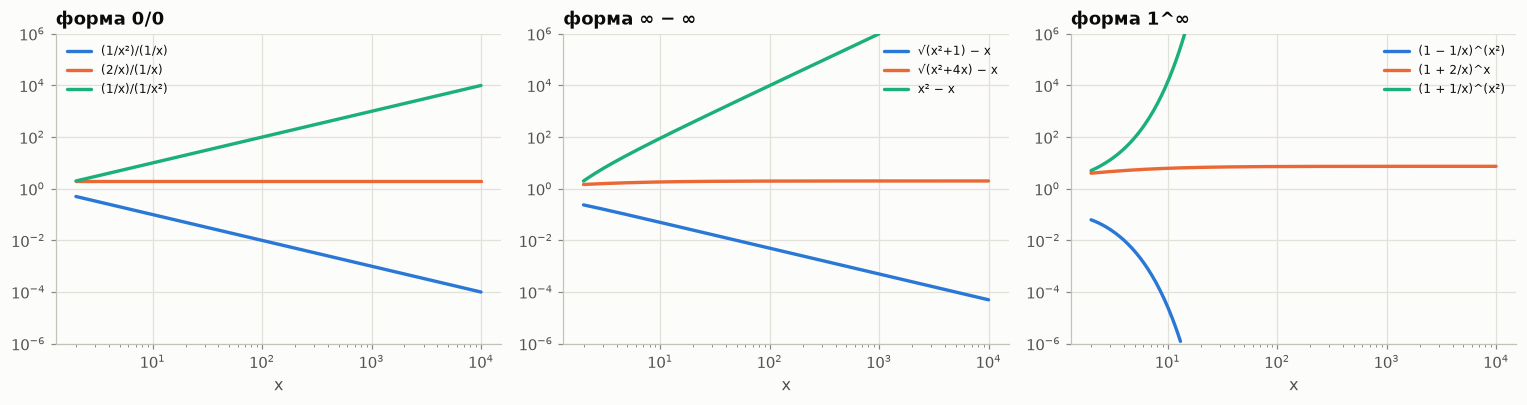

In [4]:
forms = {
    "0/0": [("(1/x²)/(1/x)", lambda x: x / x**2), ("(2/x)/(1/x)", lambda x: 2 + 0 * x), ("(1/x)/(1/x²)", lambda x: x)],
    "∞ − ∞": [("√(x²+1) − x", lambda x: 1 / (np.sqrt(x**2 + 1) + x)), ("√(x²+4x) − x", lambda x: 4 * x / (np.sqrt(x**2 + 4 * x) + x)), ("x² − x", lambda x: x**2 - x)],
    "1^∞": [("(1 − 1/x)^(x²)", lambda x: np.exp(x**2 * np.log1p(-1 / x))), ("(1 + 2/x)^x", lambda x: np.exp(x * np.log1p(2 / x))), ("(1 + 1/x)^(x²)", lambda x: np.exp(x**2 * np.log1p(1 / x)))],
}
x = np.logspace(0.3, 4, 300)
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
with np.errstate(over="ignore", divide="ignore"):
    for ax, (name, items) in zip(axes, forms.items()):
        for (lab, fn), c in zip(items, (BLUE, ORANGE, AQUA)):
            y = fn(x)
            y = np.where((y > 1e-6) & (y < 1e6), y, np.nan)
            ax.loglog(x, y, color=c, lw=2.2, label=lab)
            print(f"{name:6} {lab:16}: x = 10 → {fn(10.0):.4g}, x = 1000 → {fn(1000.0):.4g}")
        ax.set(title=f"форма {name}", xlabel="x", ylim=(1e-6, 1e6))
        ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Блок 2. Алгебраические приёмы

### 2.1. 0/0 — гонка к нулю: дробь ≈ отношение наклонов

In [5]:
cases = [("(x² − 1)/(x − 1)", lambda x: x**2 - 1, lambda x: x - 1, 1.0),
         ("(x² − 4)/(x³ − 8)", lambda x: x**2 - 4, lambda x: x**3 - 8, 2.0),
         ("sin x / x", np.sin, lambda x: x, 0.0)]
h = 1e-6
for name, num, den, a in cases:
    k1 = (num(a + h) - num(a - h)) / (2 * h)
    k2 = (den(a + h) - den(a - h)) / (2 * h)
    print(f"{name:18}: наклоны {k1:.4f} и {k2:.4f}, их отношение {k1 / k2:.4f}, дробь при a + 0.001: {num(a + 1e-3) / den(a + 1e-3):.4f}")

(x² − 1)/(x − 1)  : наклоны 2.0000 и 1.0000, их отношение 2.0000, дробь при a + 0.001: 2.0010
(x² − 4)/(x³ − 8) : наклоны 4.0000 и 12.0000, их отношение 0.3333, дробь при a + 0.001: 0.3333
sin x / x         : наклоны 1.0000 и 1.0000, их отношение 1.0000, дробь при a + 0.001: 1.0000


### 2.2. Сокращение, сопряжённое, старшая степень, ∞ − ∞

Каждый пример проверяем таблицей с обеих сторон. Схему Горнера реализуем сами и сверяем с `np.polydiv`.

In [6]:
def horner_divide(coeffs, a):
    """Делит многочлен (коэффициенты от старшего) на (x − a): частное и остаток."""
    out = [coeffs[0]]
    for c in coeffs[1:]:
        out.append(c + a * out[-1])
    return out[:-1], out[-1]


q, r = horner_divide([1, 0, -3, 2], 1)
print("x³ − 3x + 2 = (x − 1)·(", q, ") + остаток", r)
q2, r2 = horner_divide(q, 1)
print("ещё раз: частное", q2, "остаток", r2, "⇒ x³ − 3x + 2 = (x − 1)²(x + 2)")
print("np.polydiv:", np.polydiv([1, 0, -3, 2], [1, -1]))

algebra = [
    ("(x² − 5x + 6)/(x² − 4), x → 2", lambda x: (x**2 - 5 * x + 6) / (x**2 - 4), 2, -0.25),
    ("(x³ − 3x + 2)/(x³ − x² − x + 1), x → 1", lambda x: (x**3 - 3 * x + 2) / (x**3 - x**2 - x + 1), 1, 1.5),
    ("(x − 9)/(√x − 3), x → 9", lambda x: (x - 9) / (np.sqrt(x) - 3), 9, 6),
    ("(√(x+1) − 1)/(√(x+4) − 2), x → 0", lambda x: (np.sqrt(x + 1) - 1) / (np.sqrt(x + 4) - 2), 0, 2),
    ("(∛x − 1)/(x − 1), x → 1", lambda x: (np.cbrt(x) - 1) / (x - 1), 1, 1 / 3),
    ("1/(x − 1) − 2/(x² − 1), x → 1", lambda x: 1 / (x - 1) - 2 / (x**2 - 1), 1, 0.5),
]
for name, fn, a, L in algebra:
    print(f"{name}\n   {table(fn, a)}   → {L:.6g}")
    assert abs(fn(a + 1e-4) - L) < 1e-3  # ближе подходить опасно: у двойного корня портит округление

big = [("(3x² + x)/(x² + 1)", lambda x: (3 * x**2 + x) / (x**2 + 1), 3), ("√(4x² + 1)/(x + 3)", lambda x: np.sqrt(4 * x**2 + 1) / (x + 3), 2),
       ("√(x² + x) − x", lambda x: np.sqrt(x**2 + x) - x, 0.5), ("x² − √(x⁴ + 3x²)", lambda x: -3 * x**2 / (x**2 + np.sqrt(x**4 + 3 * x**2)), -1.5)]
for name, fn, L in big:
    print(f"{name:20} x = 10, 100, 1000: " + ", ".join(f"{fn(float(t)):.6f}" for t in (10, 100, 1000)) + f"   → {L}")
fi = lambda x: np.sqrt(4 * x**2 + 1) / (x + 3)  # noqa: E731
print("ловушка знака: та же дробь при x = −10, −100, −1000:", [round(float(fi(float(t))), 5) for t in (-10, -100, -1000)], "→ −2")

x³ − 3x + 2 = (x − 1)·( [1, 1, -2] ) + остаток 0
ещё раз: частное [1, 2] остаток 0 ⇒ x³ − 3x + 2 = (x − 1)²(x + 2)
np.polydiv: (array([ 1.,  1., -2.]), array([0.]))
(x² − 5x + 6)/(x² − 4), x → 2
    -0.282051   -0.253133   -0.250313   -0.249688   -0.246883   -0.219512   → -0.25
(x³ − 3x + 2)/(x³ − x² − x + 1), x → 1
     1.526316    1.502513    1.500250    1.499750    1.497512    1.476190   → 1.5
(x − 9)/(√x − 3), x → 9
     5.983287    5.998333    5.999833    6.000167    6.001666    6.016621   → 6
(√(x+1) − 1)/(√(x+4) − 2), x → 0
     2.039758    2.003771    2.000375    1.999625    1.996271    1.964481   → 2
(∛x − 1)/(x − 1), x → 1
     0.345106    0.334451    0.333445    0.333222    0.332228    0.322801   → 0.333333
1/(x − 1) − 2/(x² − 1), x → 1
     0.526316    0.502513    0.500250    0.499750    0.497512    0.476190   → 0.5
(3x² + x)/(x² + 1)   x = 10, 100, 1000: 3.069307, 3.009699, 3.000997   → 3
√(4x² + 1)/(x + 3)   x = 10, 100, 1000: 1.540383, 1.941772, 1.994018   → 2
√(x² + x) 

### 2.3. ∞ − ∞: две огромные величины, конечный зазор $\sqrt{x^2 + bx} - x \to \frac b2$

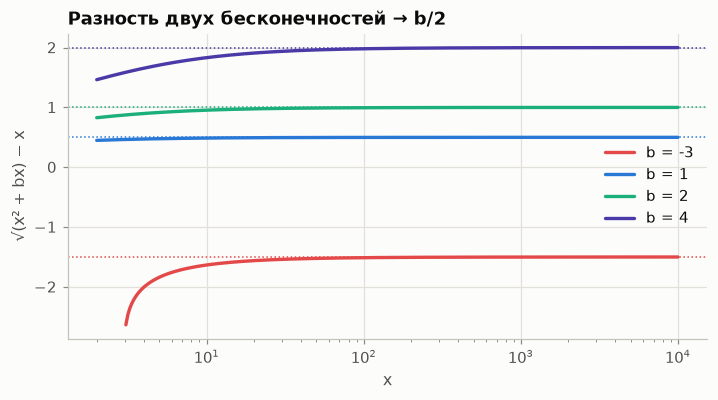

In [7]:
x = np.logspace(0.3, 4, 300)
fig, ax = plt.subplots(figsize=(7.5, 3.6))
for b, c in zip((-3, 1, 2, 4), (RED, BLUE, AQUA, VIOLET)):
    with np.errstate(invalid="ignore"):
        ax.semilogx(x, b * x / (np.sqrt(x**2 + b * x) + x), color=c, lw=2.2, label=f"b = {b}")
    ax.axhline(b / 2, color=c, ls=":", lw=1)
ax.set(xlabel="x", ylabel="√(x² + bx) − x", title="Разность двух бесконечностей → b/2")
ax.legend()
plt.show()

## Блок 3. Сжатие и замечательные пределы

### 3.1. Два милиционера: $x^2 \sin\frac1x$ и $\cos x \le \frac{\sin x}{x} \le 1$

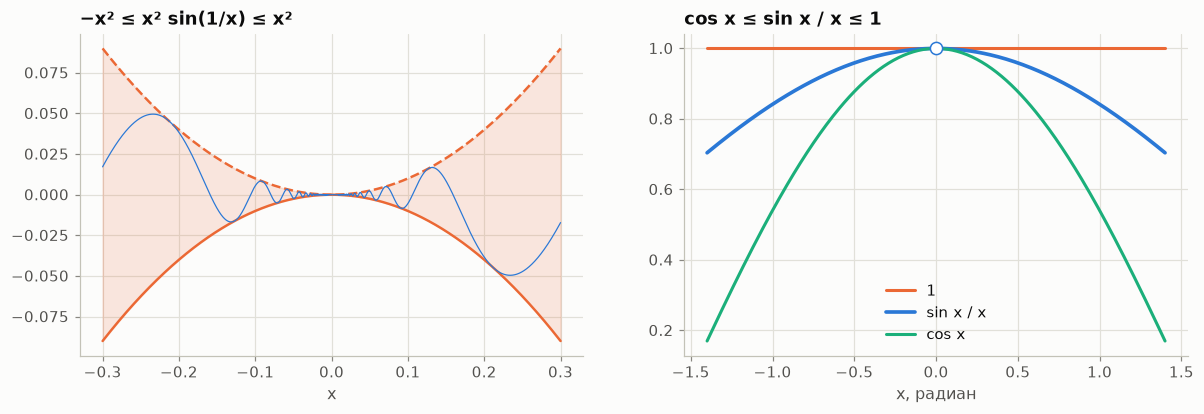

x = 0.8  : cos x = 0.696707 ≤ sin x / x = 0.896695 ≤ 1
x = 0.5  : cos x = 0.877583 ≤ sin x / x = 0.958851 ≤ 1
x = 0.1  : cos x = 0.995004 ≤ sin x / x = 0.998334 ≤ 1
x = 0.01 : cos x = 0.999950 ≤ sin x / x = 0.999983 ≤ 1
⌊x⌋/x: [0.9524, 0.995, 0.9995] → 1


In [8]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 3.8))
x = np.linspace(-0.3, 0.3, 40001)
x = x[x != 0]
a1.fill_between(x, -(x**2), x**2, color=ORANGE, alpha=0.15)
a1.plot(x, x**2, color=ORANGE, lw=1.6, ls="--")
a1.plot(x, -(x**2), color=ORANGE, lw=1.6)
a1.plot(x, x**2 * np.sin(1 / x), color=BLUE, lw=0.8)
a1.set(title="−x² ≤ x² sin(1/x) ≤ x²", xlabel="x")
x = np.linspace(-1.4, 1.4, 281)
x = x[x != 0]
a2.plot(x, np.ones_like(x), color=ORANGE, lw=2, label="1")
a2.plot(x, np.sin(x) / x, color=BLUE, lw=2.4, label="sin x / x")
a2.plot(x, np.cos(x), color=AQUA, lw=2, label="cos x")
a2.plot([0], [1], "o", mfc="white", mec=BLUE, ms=8)
a2.set(xlabel="x, радиан", title="cos x ≤ sin x / x ≤ 1")
a2.legend()
plt.show()
for x in (0.8, 0.5, 0.1, 0.01):
    print(f"x = {x:<5}: cos x = {np.cos(x):.6f} ≤ sin x / x = {np.sin(x) / x:.6f} ≤ 1")
print("⌊x⌋/x:", [round(math.floor(t) / t, 4) for t in (10.5, 100.5, 1000.5)], "→ 1")

### 3.2. Семейство синуса

In [9]:
fam = {
    "sin 3x / x → 3": lambda x: np.sin(3 * x) / x,
    "tan x / x → 1": lambda x: np.tan(x) / x,
    "(1 − cos x)/x² → 1/2": lambda x: 2 * np.sin(x / 2) ** 2 / x**2,
    "arcsin x / x → 1": lambda x: np.arcsin(x) / x,
    "sin 5x / sin 3x → 5/3": lambda x: np.sin(5 * x) / np.sin(3 * x),
    "sin(x°)/x → π/180": lambda x: np.sin(np.radians(x)) / x,
}
for name, fn in fam.items():
    print(f"{name:24}", ", ".join(f"{fn(t):.7f}" for t in (0.5, 0.1, 0.01, 0.001)))
print("π/180 =", np.pi / 180)

sin 3x / x → 3           1.9949900, 2.9552021, 2.9995500, 2.9999955
tan x / x → 1            1.0926050, 1.0033467, 1.0000333, 1.0000003
(1 − cos x)/x² → 1/2     0.4896698, 0.4995835, 0.4999958, 0.5000000
arcsin x / x → 1         1.0471976, 1.0016742, 1.0000167, 1.0000002
sin 5x / sin 3x → 5/3    0.5999751, 1.6223105, 1.6662222, 1.6666622
sin(x°)/x → π/180        0.0174531, 0.0174533, 0.0174533, 0.0174533
π/180 = 0.017453292519943295


### 3.3. Число $e$ и форма $1^\infty$: $\lim u^v = e^{\lim v(u - 1)}$

Анимация: чем чаще начисляют проценты, тем ближе ступенчатый рост к непрерывному $100 e^t$.

In [10]:
ns = [1, 2, 3, 4, 6, 12, 24, 52, 365]
t = np.linspace(0, 1, 2001)
fig, ax = plt.subplots(figsize=(6.5, 3.6), dpi=72)


def frame(i):
    n = ns[i]
    ax.clear()
    ax.plot(t, 100 * np.exp(t), "--", color=ORANGE, label="непрерывно: 100·eᵗ")
    ax.plot(t, 100 * (1 + 1 / n) ** np.floor(t * n + 1e-9), color=BLUE, lw=2, label=f"{n} раз в год")
    ax.axhline(100 * np.e, color=MUTED, ls=":")
    ax.set(ylim=(90, 285), xlabel="доля года", ylabel="тыс. ₽", title=f"через год: {100 * (1 + 1 / n) ** n:.2f} тыс. ₽")
    ax.legend(loc="upper left")
    return []


anim = animation.FuncAnimation(fig, frame, frames=len(ns), interval=800)
plt.close(fig)
display(HTML(anim.to_jshtml()))

In [11]:
seqs = {
    "(1 + 2/n)ⁿ → e²": (lambda n: 1 + 2 / n, lambda n: n),
    "(1 − 1/n)ⁿ → 1/e": (lambda n: 1 - 1 / n, lambda n: n),
    "((n+1)/(n−1))ⁿ → e²": (lambda n: (n + 1) / (n - 1), lambda n: n),
    "(1 + 1/n²)ⁿ → 1": (lambda n: 1 + 1 / n**2, lambda n: n),
    "(1 + 1/n)^(n²) → ∞": (lambda n: 1 + 1 / n, lambda n: n**2),
}
for name, (u, v) in seqs.items():
    rows = []
    for n in (10, 100, 1000):
        c = v(n) * (u(n) - 1)
        val = math.exp(v(n) * math.log(u(n))) if v(n) * math.log(u(n)) < 700 else math.inf
        rows.append(f"n={n}: v(u−1)={c:.4g}, uᵛ={val:.6g}")
    print(f"{name:22}", " | ".join(rows))

(1 + 2/n)ⁿ → e²        n=10: v(u−1)=2, uᵛ=6.19174 | n=100: v(u−1)=2, uᵛ=7.24465 | n=1000: v(u−1)=2, uᵛ=7.37431
(1 − 1/n)ⁿ → 1/e       n=10: v(u−1)=-1, uᵛ=0.348678 | n=100: v(u−1)=-1, uᵛ=0.366032 | n=1000: v(u−1)=-1, uᵛ=0.367695
((n+1)/(n−1))ⁿ → e²    n=10: v(u−1)=2.222, uᵛ=7.43878 | n=100: v(u−1)=2.02, uᵛ=7.38955 | n=1000: v(u−1)=2.002, uᵛ=7.38906
(1 + 1/n²)ⁿ → 1        n=10: v(u−1)=0.1, uᵛ=1.10462 | n=100: v(u−1)=0.01, uᵛ=1.01005 | n=1000: v(u−1)=0.001, uᵛ=1.001
(1 + 1/n)^(n²) → ∞     n=10: v(u−1)=10, uᵛ=13780.6 | n=100: v(u−1)=100, uᵛ=1.63583e+43 | n=1000: v(u−1)=1000, uᵛ=inf


### 3.4. Экспонента и логарифм около нуля — касательные

(eˣ − 1)/x → 1           1.051709, 1.005017, 1.000500, 0.995017
ln(1 + x)/x → 1          0.953102, 0.995033, 0.999500, 1.005034
(2ˣ − 1)/x → ln 2        0.717735, 0.695555, 0.693387, 0.690750
((1 + x)³ − 1)/x → 3     3.310000, 3.030100, 3.003001, 2.970100
(√(1 + x) − 1)/x → 1/2   0.488088, 0.498756, 0.499875, 0.501256
ln 2 = 0.6931471805599453


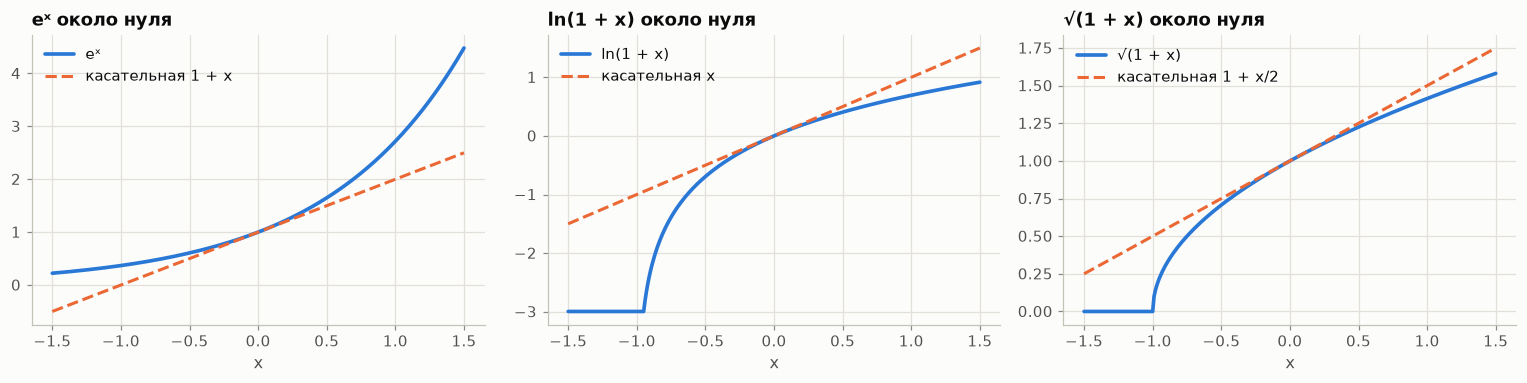

In [12]:
near = {"(eˣ − 1)/x → 1": lambda x: np.expm1(x) / x, "ln(1 + x)/x → 1": lambda x: np.log1p(x) / x,
        "(2ˣ − 1)/x → ln 2": lambda x: (2.0**x - 1) / x, "((1 + x)³ − 1)/x → 3": lambda x: ((1 + x) ** 3 - 1) / x,
        "(√(1 + x) − 1)/x → 1/2": lambda x: (np.sqrt(1 + x) - 1) / x}
for name, fn in near.items():
    print(f"{name:24}", ", ".join(f"{fn(t):.6f}" for t in (0.1, 0.01, 0.001, -0.01)))
print("ln 2 =", np.log(2))

x = np.linspace(-1.5, 1.5, 301)
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for ax, (lab, y, tan, tl) in zip(axes, [("eˣ", np.exp(x), 1 + x, "1 + x"), ("ln(1 + x)", np.log1p(np.maximum(x, -0.95)), x, "x"), ("√(1 + x)", np.sqrt(np.maximum(1 + x, 0)), 1 + x / 2, "1 + x/2")]):
    ax.plot(x, y, color=BLUE, lw=2.4, label=lab)
    ax.plot(x, tan, "--", color=ORANGE, lw=2, label="касательная " + tl)
    ax.set(xlabel="x", title=lab + " около нуля")
    ax.legend()
plt.tight_layout()
plt.show()

## Блок 4. Сравнение скоростей

### 4.1. Порядок малости — наклон на двойной логарифмической шкале

sin x         : наклон между 0.001 и 0.01 = 1.0000
1 − cos x     : наклон между 0.001 и 0.01 = 2.0000
x − sin x     : наклон между 0.001 и 0.01 = 3.0000
tan x − sin x : наклон между 0.001 и 0.01 = 3.0000
√x            : наклон между 0.001 и 0.01 = 0.5000
−x ln x       : наклон между 0.001 и 0.01 = 0.8239


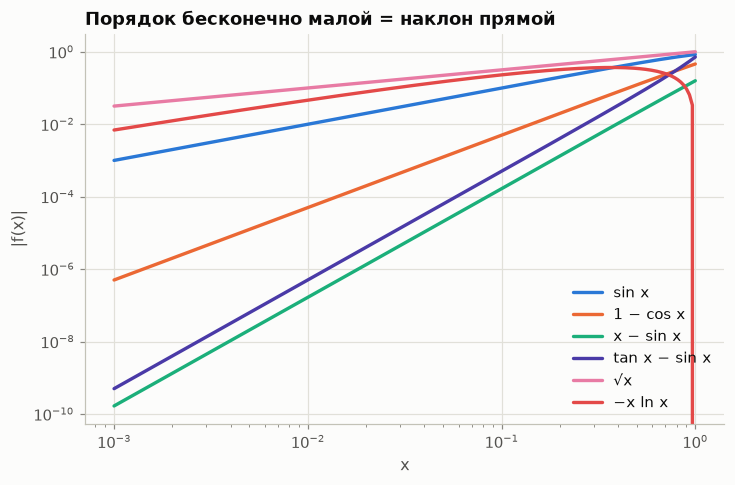

In [13]:
inf_small = {"sin x": np.sin, "1 − cos x": lambda x: 2 * np.sin(x / 2) ** 2, "x − sin x": lambda x: x - np.sin(x),
             "tan x − sin x": lambda x: np.tan(x) * 2 * np.sin(x / 2) ** 2, "√x": np.sqrt, "−x ln x": lambda x: -x * np.log(x)}
x = np.logspace(-3, 0, 200)
fig, ax = plt.subplots(figsize=(7.5, 4.6))
for (name, fn), c in zip(inf_small.items(), (BLUE, ORANGE, AQUA, VIOLET, MAGENTA, RED)):
    ax.loglog(x, fn(x), color=c, lw=2.2, label=name)
    s = (np.log(fn(0.01)) - np.log(fn(0.001))) / np.log(10)
    print(f"{name:14}: наклон между 0.001 и 0.01 = {s:.4f}")
ax.set(xlabel="x", ylabel="|f(x)|", title="Порядок бесконечно малой = наклон прямой")
ax.legend()
plt.show()

### 4.2. Замена на эквивалентные — и ловушка разностей

In [14]:
eq = {
    "ln(1+3x)/sin 2x (≈ 3x/2x)": (lambda x: np.log1p(3 * x) / np.sin(2 * x), 1.5, 1.5),
    "(1 − cos 4x)/x² (≈ 8x²/x²)": (lambda x: (1 - np.cos(4 * x)) / x**2, 8, 8),
    "(tan x − sin x)/x³ ловушка": (lambda x: (np.tan(x) - np.sin(x)) / x**3, 0, 0.5),
    "(sin x − x)/x³ ловушка": (lambda x: (np.sin(x) - x) / x**3, 0, -1 / 6),
    "(eˣ − 1 − x)/x² ловушка": (lambda x: (np.expm1(x) - x) / x**2, 0, 0.5),
}
for name, (fn, naive, L) in eq.items():
    vals = ", ".join(f"{fn(t):.7f}" for t in (0.1, 0.01, 0.001))
    print(f"{name:28} {vals}   наивно {naive}, верно {L:.6g}")
print("а если подойти слишком близко — округление (tan x − sin x)/x³:", [round(float((np.tan(t) - np.sin(t)) / t**3), 6) for t in (1e-5, 1e-6, 1e-7)])

ln(1+3x)/sin 2x (≈ 3x/2x)    1.3206078, 1.4780386, 1.4977555   наивно 1.5, верно 1.5
(1 − cos 4x)/x² (≈ 8x²/x²)   7.8939006, 7.9989334, 7.9999893   наивно 8, верно 8
(tan x − sin x)/x³ ловушка   0.5012554, 0.5000125, 0.5000001   наивно 0, верно 0.5
(sin x − x)/x³ ловушка       -0.1665834, -0.1666658, -0.1666667   наивно 0, верно -0.166667
(eˣ − 1 − x)/x² ловушка      0.5170918, 0.5016708, 0.5001667   наивно 0, верно 0.5
а если подойти слишком близко — округление (tan x − sin x)/x³: [0.5, 0.499961, 0.502926]


### 4.3. Иерархия роста: сравниваем логарифмы

In [15]:
for x in (10, 20, 50, 100, 1000):
    lg = lambda v: v / math.log(10)  # noqa: E731
    print(f"x = {x:>4}: lg x⁵ = {lg(5 * math.log(x)):7.2f}, lg eˣ = {lg(x):7.2f}, lg x! = {lg(math.lgamma(x + 1)):8.2f}, lg xˣ = {lg(x * math.log(x)):8.2f}")
roots = [optimize.brentq(lambda t: 5 * math.log(t) - t, 1.01, 2), optimize.brentq(lambda t: 5 * math.log(t) - t, 5, 20)]
print("x⁵ = eˣ при x ≈", [round(r, 4) for r in roots])
print("x¹⁰⁰ = 1.01ˣ при x ≈", round(math.exp(optimize.brentq(lambda s: 100 * s - math.exp(s) * math.log(1.01), 5, 20))))
print("ln x = x^0.1 при x ≈", f"{math.exp(optimize.brentq(lambda s: math.log(s) - 0.1 * s, 10, 100)):.3e}")
for a in (1, 0.5, 0.1):
    print(f"a = {a}: минимум xᵃ ln x = {-1 / (a * math.e):.4f} при x = {math.exp(-1 / a):.3g}")
print("xˣ:", [round(t**t, 4) for t in (0.1, 0.01, 0.001)], "  ⁿ√n:", [round(n ** (1 / n), 4) for n in (3, 10, 100, 1000)])

x =   10: lg x⁵ =    5.00, lg eˣ =    4.34, lg x! =     6.56, lg xˣ =    10.00
x =   20: lg x⁵ =    6.51, lg eˣ =    8.69, lg x! =    18.39, lg xˣ =    26.02
x =   50: lg x⁵ =    8.49, lg eˣ =   21.71, lg x! =    64.48, lg xˣ =    84.95
x =  100: lg x⁵ =   10.00, lg eˣ =   43.43, lg x! =   157.97, lg xˣ =   200.00
x = 1000: lg x⁵ =   15.00, lg eˣ =  434.29, lg x! =  2567.60, lg xˣ =  3000.00
x⁵ = eˣ при x ≈ [1.2959, 12.7132]
x¹⁰⁰ = 1.01ˣ при x ≈ 117308
ln x = x^0.1 при x ≈ 3.431e+15
a = 1: минимум xᵃ ln x = -0.3679 при x = 0.368
a = 0.5: минимум xᵃ ln x = -0.7358 при x = 0.135
a = 0.1: минимум xᵃ ln x = -3.6788 при x = 4.54e-05
xˣ: [0.7943, 0.955, 0.9931]   ⁿ√n: [1.4422, 1.2589, 1.0471, 1.0069]


## Блок 5. Непрерывность

### 5.1. Разрывы и доопределение. Сверка с NumPy и SciPy

`np.sinc` уже доопределена в нуле, `scipy.special.xlogy(p, p)` считает $p \ln p$ с соглашением $0 \ln 0 = 0$ —
это доопределение по непрерывности, ведь $\lim_{p \to 0^+} p \ln p = 0$.

In [16]:
print("np.sinc(0) =", np.sinc(0.0), "  sin(πx)/(πx) при x = 1e-8:", np.sin(np.pi * 1e-8) / (np.pi * 1e-8))
p = np.array([0.0, 0.25, 0.75])
print("xlogy(p, p) =", special.xlogy(p, p), "  энтропия H =", -special.xlogy(p, p).sum())
with np.errstate(divide="ignore", invalid="ignore"):
    print("наивно p·log p =", p * np.log(p))
for name, fn, a in [("|x|/x", lambda x: abs(x) / x, 0), ("sin 2x / x", lambda x: math.sin(2 * x) / x, 0), ("e^(1/x)", lambda x: math.exp(1 / x) if 1 / x < 700 else math.inf, 0)]:
    print(f"{name:10}: слева {fn(a - 1e-3):.6g}, справа {fn(a + 1e-3):.6g}")

np.sinc(0) = 1.0   sin(πx)/(πx) при x = 1e-8: 0.9999999999999998
xlogy(p, p) = [ 0.         -0.34657359 -0.21576155]   энтропия H = 0.5623351446188083
наивно p·log p = [        nan -0.34657359 -0.21576155]
|x|/x     : слева -1, справа 1
sin 2x / x: слева 2, справа 2
e^(1/x)   : слева 0, справа inf


### 5.2. Склейка кусков: потери Хьюбера в библиотеке курса

$L_\delta(r) = \frac{r^2}{2}$ при $|r| \le \delta$ и $\delta(|r| - c)$ дальше. Непрерывность требует $c = \frac\delta2$ —
так и записано в `gbcourse.losses`. Проверим значения и наклоны в стыке.

In [17]:
for d in (0.5, 1.0, 2.0):
    hub = get_loss("huber", delta=d)
    e = 1e-7
    left, right = hub.pointwise(np.array([0.0]), np.array([-(d - e)]))[0], hub.pointwise(np.array([0.0]), np.array([-(d + e)]))[0]
    gl, gr = hub.gradient(np.array([0.0]), np.array([-(d - e)]))[0], hub.gradient(np.array([0.0]), np.array([-(d + e)]))[0]
    print(f"δ = {d}: значения в стыке {left:.6f} | {right:.6f}, градиенты {gl:.6f} | {gr:.6f}")
    assert abs(left - right) < 1e-6 and abs(gl - gr) < 1e-6

δ = 0.5: значения в стыке 0.125000 | 0.125000, градиенты -0.500000 | -0.500000
δ = 1.0: значения в стыке 0.500000 | 0.500000, градиенты -1.000000 | -1.000000
δ = 2.0: значения в стыке 2.000000 | 2.000000, градиенты -2.000000 | -2.000000


### 5.3. Теорема о промежуточном значении: деление пополам против `scipy.optimize.bisect`

In [18]:
def bisect(fn, lo, hi, tol=1e-12):
    assert fn(lo) * fn(hi) < 0, "нужна смена знака"
    k = 0
    while hi - lo > tol:
        mid = (lo + hi) / 2
        lo, hi = (mid, hi) if fn(lo) * fn(mid) > 0 else (lo, mid)
        k += 1
    return (lo + hi) / 2, k


for name, fn, lo, hi in [("x³ − 2", lambda x: x**3 - 2, 1.0, 2.0), ("cos x − x", lambda x: math.cos(x) - x, 0.0, 1.0), ("x³ − x − 1", lambda x: x**3 - x - 1, 1.0, 2.0)]:
    r, k = bisect(fn, lo, hi)
    rs = optimize.bisect(fn, lo, hi, xtol=1e-12)
    print(f"{name:10}: наш {r:.12f} ({k} шагов), scipy {rs:.12f}")
    assert abs(r - rs) < 1e-10
r, _ = bisect(lambda x: 1 / (x - 0.6), 0.0, 1.0)
print(f"1/(x − 0.6): «корень» {r:.10f}, а значение там {1 / (r - 0.6):.3g} — полюс, а не корень!")

x³ − 2    : наш 1.259921049895 (40 шагов), scipy 1.259921049895
cos x − x : наш 0.739085133215 (40 шагов), scipy 0.739085133216
x³ − x − 1: наш 1.324717957245 (40 шагов), scipy 1.324717957245
1/(x − 0.6): «корень» 0.6000000000, а значение там -1.1e+13 — полюс, а не корень!


### 5.4. Теорема Вейерштрасса: у log-loss на разделимых данных нет минимума

$\ln(1 + e^{-w})$ убывает к нулю, не достигая его. Штраф $\frac\lambda2 w^2$ возвращает минимум.

λ = 0.1: минимум в w* = 1.6335, потери 0.3118
λ = 0.01: минимум в w* = 3.3593, потери 0.0906
λ = 0.001: минимум в w* = 5.2452, потери 0.0190


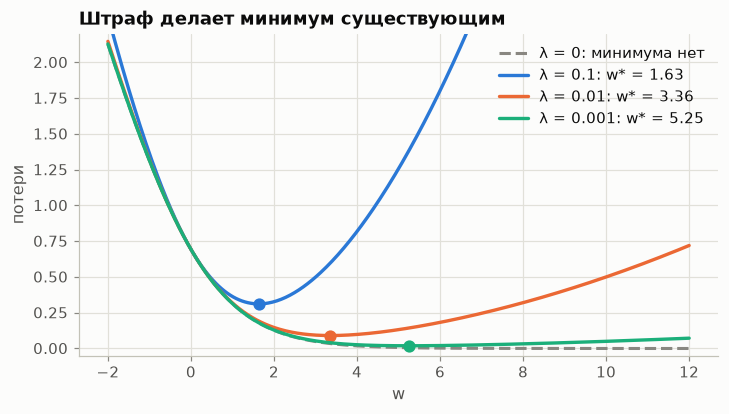

In [19]:
w = np.linspace(-2, 12, 400)
fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.plot(w, np.logaddexp(0, -w), color=MUTED, lw=2, ls="--", label="λ = 0: минимума нет")
for lam, c in zip((0.1, 0.01, 0.001), (BLUE, ORANGE, AQUA)):
    res = optimize.minimize_scalar(lambda v, lam=lam: np.logaddexp(0, -v) + lam * v * v / 2, bounds=(-5, 100), method="bounded")
    ax.plot(w, np.logaddexp(0, -w) + lam * w**2 / 2, color=c, lw=2.2, label=f"λ = {lam}: w* = {res.x:.2f}")
    ax.plot([res.x], [res.fun], "o", color=c, ms=7)
    print(f"λ = {lam}: минимум в w* = {res.x:.4f}, потери {res.fun:.4f}")
ax.set(ylim=(-0.05, 2.2), xlabel="w", ylabel="потери", title="Штраф делает минимум существующим")
ax.legend()
plt.show()

## Блок 6. Пределы и непрерывность в ML

### 6.1. Деревья — разрывные функции

Модель бустинга из пней (библиотека курса). Считаем скачки и долю сетки, где модель горизонтальна.

M =   3: скачков   3, на 99.98 % сетки модель горизонтальна (производная 0)
M =  20: скачков  20, на 99.90 % сетки модель горизонтальна (производная 0)
M = 120: скачков  80, на 99.60 % сетки модель горизонтальна (производная 0)


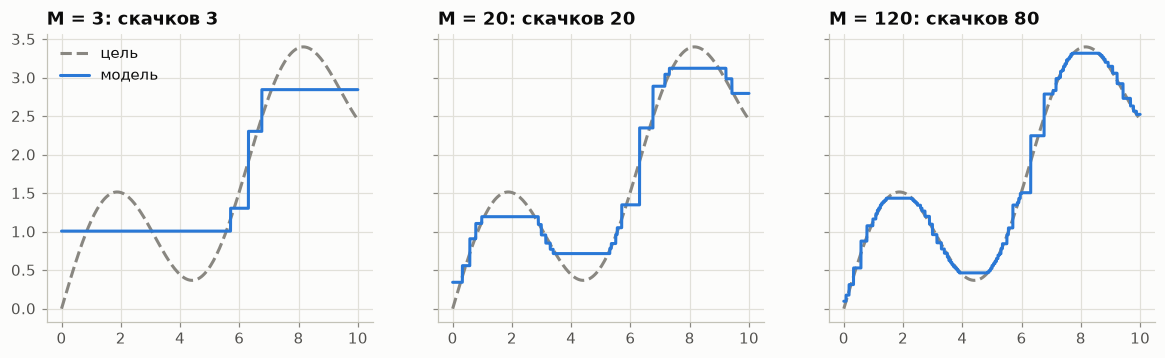

In [20]:
xg = np.linspace(0, 10, 200)
yg = np.sin(xg) + 0.3 * xg
fine = np.linspace(0, 10, 20001)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), sharey=True)
for ax, M in zip(axes, (3, 20, 120)):
    model = GBRegressor(n_estimators=M, learning_rate=0.5, max_depth=1).fit(xg.reshape(-1, 1), yg)
    pred = model.predict(fine.reshape(-1, 1))
    jumps = int(np.sum(np.abs(np.diff(pred)) > 1e-12))
    zero = np.mean(np.abs(np.diff(pred)) < 1e-12)
    ax.plot(xg, yg, "--", color=MUTED, label="цель")
    ax.plot(fine, pred, color=BLUE, lw=2, label="модель")
    ax.set_title(f"M = {M}: скачков {jumps}")
    print(f"M = {M:3d}: скачков {jumps:3d}, на {100 * zero:.2f} % сетки модель горизонтальна (производная 0)")
axes[0].legend()
plt.show()

### 6.2. Accuracy ступенчата, log-loss гладкий

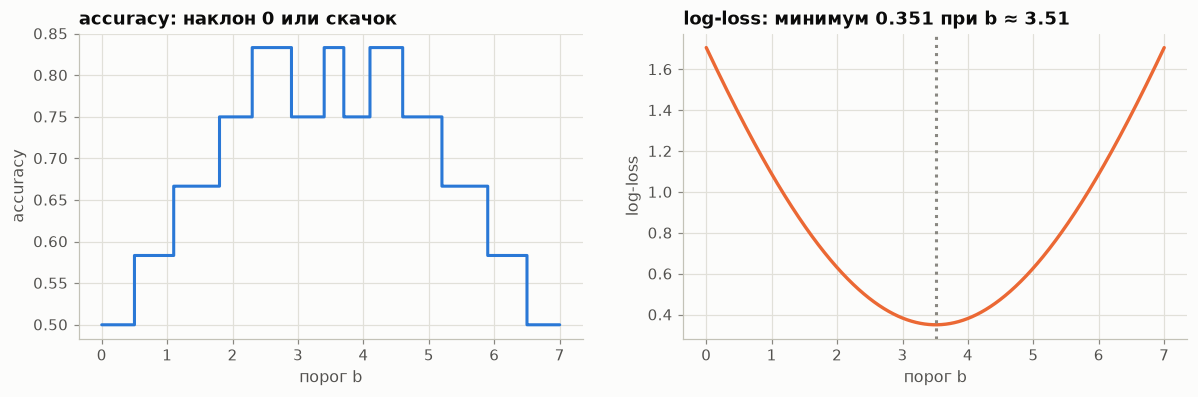

максимум accuracy 0.833 на участках: [(2.3, 2.9), (3.4, 3.7), (4.1, 4.6)]
в минимуме log-loss accuracy = 0.833


In [21]:
X = np.array([0.5, 1.1, 1.8, 2.3, 3.4, 4.1, 2.9, 3.7, 4.6, 5.2, 5.9, 6.5])
y = np.array([0] * 6 + [1] * 6)
bs = np.linspace(0, 7, 7001)
acc = np.array([np.mean((X > b) == (y == 1)) for b in bs])
ll = np.array([np.mean(np.logaddexp(0, 1.5 * (X - b)) - y * 1.5 * (X - b)) for b in bs])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 3.6))
a1.step(bs, acc, where="post", color=BLUE, lw=2)
a1.set(xlabel="порог b", ylabel="accuracy", title="accuracy: наклон 0 или скачок")
a2.plot(bs, ll, color=ORANGE, lw=2.2)
a2.axvline(bs[ll.argmin()], color=MUTED, ls=":")
a2.set(xlabel="порог b", ylabel="log-loss", title=f"log-loss: минимум {ll.min():.3f} при b ≈ {bs[ll.argmin()]:.2f}")
plt.show()
plateaus = np.flatnonzero(np.diff(np.r_[False, acc == acc.max(), False].astype(int)))
print("максимум accuracy", round(acc.max(), 3), "на участках:", [(round(float(bs[s]), 2), round(float(bs[e - 1]), 2)) for s, e in zip(plateaus[::2], plateaus[1::2])])
print("в минимуме log-loss accuracy =", round(acc[ll.argmin()], 3))

### 6.3. Число $e$ в бэггинге и бустинге

Бутстрэп — генератором курса (тот же, что в браузере): доля не попавших → $1/e$, распределение кратностей →
Пуассон с параметром 1. Бустинг: $(1 - \nu)^{T/\nu} \to e^{-T}$.

In [22]:
rng = Mulberry32(1)
for n in (10, 100, 1000, 10000):
    counts = np.bincount([rng.randint(n) for _ in range(n)], minlength=n)
    print(f"n = {n:>5}: не попали {np.mean(counts == 0):.4f}, формула {(1 - 1 / n) ** n:.4f}, 1/e = {1 / np.e:.4f}; "
          f"доли кратностей 0..3: {np.round(np.bincount(counts, minlength=4)[:4] / n, 3)} (Пуассон: {np.round([np.exp(-1) / math.factorial(k) for k in range(4)], 3)})")
T = 2
for nu in (0.5, 0.25, 0.1, 0.01, 0.001):
    print(f"ν = {nu:<6} M = {round(T / nu):>5}: (1 − ν)^M = {(1 - nu) ** round(T / nu):.5f}   (e^−T = {np.exp(-T):.5f})")

n =    10: не попали 0.3000, формула 0.3487, 1/e = 0.3679; доли кратностей 0..3: [0.3 0.5 0.1 0.1] (Пуассон: [0.368 0.368 0.184 0.061])
n =   100: не попали 0.3800, формула 0.3660, 1/e = 0.3679; доли кратностей 0..3: [0.38 0.33 0.21 0.07] (Пуассон: [0.368 0.368 0.184 0.061])
n =  1000: не попали 0.3680, формула 0.3677, 1/e = 0.3679; доли кратностей 0..3: [0.368 0.366 0.188 0.057] (Пуассон: [0.368 0.368 0.184 0.061])
n = 10000: не попали 0.3702, формула 0.3679, 1/e = 0.3679; доли кратностей 0..3: [0.37  0.367 0.179 0.063] (Пуассон: [0.368 0.368 0.184 0.061])
ν = 0.5    M =     4: (1 − ν)^M = 0.06250   (e^−T = 0.13534)
ν = 0.25   M =     8: (1 − ν)^M = 0.10011   (e^−T = 0.13534)
ν = 0.1    M =    20: (1 − ν)^M = 0.12158   (e^−T = 0.13534)
ν = 0.01   M =   200: (1 − ν)^M = 0.13398   (e^−T = 0.13534)
ν = 0.001  M =  2000: (1 − ν)^M = 0.13520   (e^−T = 0.13534)


### 6.4. Устойчивые формулы: асимптотики против переполнения

Сверяем наивную и устойчивую формулы с `gbcourse.losses` и `scipy.special.logsumexp`.

In [23]:
F = np.array([-800.0, -30.0, 0.0, 30.0, 40.0, 800.0])
with np.errstate(over="ignore"):
    naive = np.log(1 + np.exp(-F))
stable = np.maximum(-F, 0) + np.log1p(np.exp(-np.abs(F)))
lib = get_loss("logistic").pointwise(np.ones_like(F), F)
for f_, a, b, c in zip(F, naive, stable, lib):
    print(f"F = {f_:6.0f}: наивно {a:.6g}, устойчиво {b:.6g}, gbcourse {c:.6g}")
assert np.allclose(stable, lib, rtol=1e-6, atol=1e-12)
z = np.array([1000.0, 1001.0, 1002.0])
with np.errstate(over="ignore"):
    print("log-sum-exp: наивно", np.log(np.exp(z).sum()), "| устойчиво", z.max() + np.log(np.exp(z - z.max()).sum()), "| scipy", special.logsumexp(z))

F =   -800: наивно inf, устойчиво 800, gbcourse 800
F =    -30: наивно 30, устойчиво 30, gbcourse 30
F =      0: наивно 0.693147, устойчиво 0.693147, gbcourse 0.693147
F =     30: наивно 9.34808e-14, устойчиво 9.35762e-14, gbcourse 9.23706e-14
F =     40: наивно 0, устойчиво 4.24835e-18, gbcourse 0
F =    800: наивно 0, устойчиво 0, gbcourse 0
log-sum-exp: наивно inf | устойчиво 1002.4076059644444 | scipy 1002.4076059644444


При $F = 30$ наивная формула теряет точность в $\ln(1 + \text{крошка})$ (третий знак), при $F \ge 37$ даёт ровно 0;
при $F = -800$ — `inf`. Устойчивая формула (и `np.logaddexp`) верна везде. Библиотека курса тоже никогда
не переполняется, но её общая формула $\max(F, 0) + \ln(1 + e^{-|F|}) - yF$ при $y = 1$ и больших $F$ вычитает
почти равные числа ($30 - 30$) и теряет крошечные потери: $9.237 \cdot 10^{-14}$ вместо $9.358 \cdot 10^{-14}$ при
$F = 30$ и 0 при $F = 40$. Абсолютная ошибка порядка $10^{-15}$ — для суммы потерь несущественно.

## Упражнения

Условия — `exercises/tasks.md`, решения с проверкой — `exercises/solutions.py`.

1. ★☆☆ Подстановка, сокращение и старшая степень.
2. ★☆☆ Семейство синуса.
3. ★★☆ Сопряжённое: корни сверху и снизу.
4. ★★☆ $\infty - \infty$ с корнем и логарифмами.
5. ★★☆ Форма $1^\infty$.
6. ★★☆ Эквивалентности.
7. ★★☆ Виды разрывов.
8. ★★☆ Склейка кусков.
9. ★★☆ Деление пополам: $\cos x = x$.
10. ★★★ Ловушка разностей.
11. ★★★ Иерархия роста: где $x^{100}$ уступает $1.01^x$.
12. ★★★ Бэггинг и число $e$.